In [68]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.patches as mpatches
from scipy.integrate import simpson  
from joblib import Parallel, delayed
import matplotlib.cm as cm
import matplotlib.colors as colors

In [69]:
#function
#T_l不可逆
def gr_L_keni(T_l, A_l, tol=1e-16):
    N = T_l.shape[0]
    I = np.eye(N)

    A = np.block([
        [np.zeros((N, N)), I],
        [-T_l.conj().T, A_l]
    ])

    B = np.block([
        [I, np.zeros((N, N))],
        [np.zeros((N, N)), T_l]
    ])

    eigvals, eigvecs = eig(A, B)

    lambdas = []
    modes = []

    for i, lam in enumerate(eigvals):
        if np.abs(lam) < 1 - tol:   # 衰减模式
            x = eigvecs[:N, i]
            x /= np.linalg.norm(x)
            lambdas.append(lam)
            modes.append(x)

    X = np.column_stack(modes)
    Lambda = np.diag(lambdas)
    #print(Lambda.shape,X.shape)
    F = X @ Lambda @ np.linalg.inv(X)

    gL = np.linalg.inv(A_l - T_l @ F)

    return gL

def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    #check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    #max_err = np.max(np.abs(check))

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E, eta=1e-6):

    d_device = H_q_list[0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)


    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    A_DD = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
 
        H_q_i = H_q_list[i]

        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == xshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        # 加上层间跃迁
        if i < xshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T

    A_DD = np.block(A_DD)

    G_DD_r = np.linalg.inv(A_DD)
    
    return G_DD_r, Sigma_R, Sigma_L

def Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E, eta=1e-6):
    N = xshumu
    
    d_device = H_q_list[0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    V = T_21
    V_dagger = V.conj().T
    
    # gL 数组存储从左向右扫描的局域有效格林函数
    gL = np.zeros((N, d_device, d_device), dtype=complex)
    
    # 1. 第 0 层 (最左侧)：包含本层哈密顿量和左电极自能
    gL[0] = np.linalg.inv(EI_device - H_q_list[0] - Sigma_L)
    
    # 2. 中间层：通过 Dyson 方程，把左侧所有层的物理效应折叠为本层的等效自能
    for n in range(1, N-1):
        Sigma_eff_L = V_dagger @ gL[n-1] @ V
        gL[n] = np.linalg.inv(EI_device - H_q_list[n] - Sigma_eff_L)
        
    # 3. 第 N-1 层 (最右侧)：包含左侧传播来的等效自能，以及真实的右电极自能
    Sigma_eff_L_last = V_dagger @ gL[N-2] @ V
    gL[N-1] = np.linalg.inv(EI_device - H_q_list[N-1] - Sigma_eff_L_last - Sigma_R)
    
    # 4. 回溯提取透射矩阵 G_RL (即 G_{N-1, 0}，波函数从左侧 0 传播到右侧 N-1)
    G_RL = gL[N-1].copy()
    for n in range(N-2, -1, -1):
        G_RL = G_RL @ V_dagger @ gL[n]

    # 直接返回这三个计算电导的必需品，G_RL 的维度是 160x160
    return G_RL, Sigma_R, Sigma_L

def calc_T_eff(Bz_val, E_val):
    # 1. 动态更新层间跃迁矩阵
    T_21 = H_hop(B, a, A, xshumu, Nd, Bz_val)
    
    # 2. 计算格林函数 (传入全局组装好的不均匀 Sigma_virtual_big)
    G_all, Sigma_R, Sigma_L = Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E_val, Sigma_virtual_big, eta=1e-6)
    
    d_device = Sigma_L.shape[0] 
    
    # 3. 提取非零小矩阵块
    slices = []
    small_gammas = []
    
    # --- 左极 ---
    gamma_L_small = 1j * (Sigma_L - Sigma_L.conj().T)
    slices.append((0, d_device))
    small_gammas.append(gamma_L_small)
    
    # --- 虚拟探针 (核心修改：从 T_d_list 中按位置读取特定的展宽) ---
    for i in range(total_sites):
        slices.append((2 * i, 2 * i + 2))
        small_gammas.append(T_d_list[i])
        
    # --- 右极 ---
    gamma_R_small = 1j * (Sigma_R - Sigma_R.conj().T)
    slices.append((M - d_device, M))
    small_gammas.append(gamma_R_small)
    
    num_probes = len(slices)
    
    # 4. 极速计算透射矩阵 T_ij
    T_matrix = np.zeros((num_probes, num_probes), dtype=float)
    for i in range(num_probes):
        start_i, end_i = slices[i]
        gamma_i = small_gammas[i]
        for j in range(num_probes):
            if i == j: continue 
            start_j, end_j = slices[j]
            gamma_j = small_gammas[j]
            
            G_ij = G_all[start_i:end_i, start_j:end_j]
            Ga_ji = G_ij.conj().T
            T_matrix[i, j] = np.real(np.trace(gamma_i @ G_ij @ gamma_j @ Ga_ji))

    # 5. 解 Büttiker 虚拟电压方程
    V_L = 1.0
    V_R = 0.0
    W = np.zeros((total_sites, total_sites), dtype=float)
    B_vec = np.zeros(total_sites, dtype=float)
    
    for p in range(1, total_sites + 1):  
        row = p - 1  
        W[row, row] = np.sum(T_matrix[p, :])
        for q in range(1, total_sites + 1):
            if p != q:
                col = q - 1
                W[row, col] = -T_matrix[p, q]
        B_vec[row] = T_matrix[p, 0] * V_L + T_matrix[p, num_probes - 1] * V_R

    V_virtual = np.linalg.solve(W, B_vec)

    # 6. 整合有效电导 T_eff
    T_eff = T_matrix[0, num_probes - 1] * (V_L - V_R) 
    for v in range(1, total_sites + 1):
        T_eff += T_matrix[0, v] * (V_L - V_virtual[v - 1])
        
    return T_eff

def Gr_DD_xuni(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E, Sigma_virtual_big, eta=1e-6):

    d_device = H_q_list[0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    A_DD = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        H_q_i = H_q_list[i]

        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == xshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        # 加上层间跃迁
        if i < xshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T

    A_DD = np.block(A_DD)

    # ==========================================
    # 核心修改：在求逆前，减去虚拟探针的退相干自能矩阵
    # ==========================================
    A_DD = A_DD - Sigma_virtual_big

    # 对全矩阵求逆，得到包含退相干效应的总推迟格林函数
    G_DD_r = np.linalg.inv(A_DD)
    
    return G_DD_r, Sigma_R, Sigma_L

# =====================================================================
# 1. 单通道的有效电导求解器 (包含 Büttiker 虚拟探针逻辑)
# =====================================================================
def calc_T_eff_single(E_val, mats, xshumu, T_d_list, Sigma_virtual_big, eta=1e-6):
    """
    计算单个通道下的退相干透射率
    """
    # 1. 提取当前通道的矩阵
    H_q_list = mats["H_q_list"]
    T_21 = mats["T_21"]
    H_l = mats["H_l"]
    T_l = mats["T_l"]
    H_r = mats["H_r"]
    T_r = mats["T_r"]
    T_LD = mats["T_LD"]
    T_RD = mats["T_RD"]

    # 2. 调用全矩阵求逆求解器，获取总格林函数
    G_all, Sigma_R, Sigma_L = Gr_DD_xuni(
        H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, 
        xshumu, E_val, Sigma_virtual_big, eta=eta
    )
    
    # 3. 准备展宽矩阵和切片索引
    d_device = Sigma_L.shape[0]  # 这里是 2
    M = xshumu * d_device        # 全矩阵维度
    
    slices = []
    small_gammas = []
    
    # --- 左极 (真实电极, 索引 0) ---
    gamma_L_small = 1j * (Sigma_L - Sigma_L.conj().T)
    slices.append((0, d_device))
    small_gammas.append(gamma_L_small)
    
    # --- 虚拟探针 (对应内部每一个格点, 索引 1 到 xshumu) ---
    for i in range(xshumu):
        slices.append((d_device * i, d_device * i + d_device))
        small_gammas.append(T_d_list[i])
        
    # --- 右极 (真实电极, 索引 xshumu + 1) ---
    gamma_R_small = 1j * (Sigma_R - Sigma_R.conj().T)
    slices.append((M - d_device, M))
    small_gammas.append(gamma_R_small)
    
    num_probes = len(slices) # 总探针数：xshumu + 2
    
    # 4. 计算多端透射矩阵 T_ij = Tr(Gamma_i * G_ij * Gamma_j * Ga_ji)
    T_matrix = np.zeros((num_probes, num_probes), dtype=float)
    for i in range(num_probes):
        start_i, end_i = slices[i]
        gamma_i = small_gammas[i]
        for j in range(num_probes):
            if i == j: continue 
            start_j, end_j = slices[j]
            gamma_j = small_gammas[j]
            
            G_ij = G_all[start_i:end_i, start_j:end_j]
            Ga_ji = G_ij.conj().T
            T_matrix[i, j] = np.real(np.trace(gamma_i @ G_ij @ gamma_j @ Ga_ji))

    # 5. 解 Büttiker 虚拟探针的电压分布方程
    V_L = 1.0
    V_R = 0.0
    
    # 建立系数矩阵 W (维度为 xshumu * xshumu)
    W = np.zeros((xshumu, xshumu), dtype=float)
    B_vec = np.zeros(xshumu, dtype=float)
    
    # p 和 q 是 T_matrix 中的虚拟探针索引 (1 到 xshumu)
    for p in range(1, xshumu + 1):  
        row = p - 1  
        # W 对角元: 流出到所有其他端（包括左右极）的透射率之和
        W[row, row] = np.sum(T_matrix[p, :]) - T_matrix[p, p]
        
        # W 非对角元: 虚拟探针之间的耦合
        for q in range(1, xshumu + 1):
            if p != q:
                col = q - 1
                W[row, col] = -T_matrix[p, q]
                
        # 边界条件 B: 来源于左右真实极注入的载流子
        B_vec[row] = T_matrix[p, 0] * V_L + T_matrix[p, num_probes - 1] * V_R

    # 解线性方程组，求出让各个格点处净电流为零的局部平衡电压
    V_virtual = np.linalg.solve(W, B_vec)

    # 6. 计算该通道的最终有效电导 T_eff
    # 第一部分：纯相干的直接透射 (从左极直接射入右极)
    T_eff = T_matrix[0, num_probes - 1] * (V_L - V_R) 
    # 第二部分：非相干透射 (从左极射入虚拟探针失去相位后，重新发射出来的贡献)
    for v in range(1, xshumu + 1):
        T_eff += T_matrix[0, v] * (V_L - V_virtual[v - 1])
        
    return T_eff


# =====================================================================
# 2. 对所有通道求和的封装函数 (适用于给 joblib 并行调用)
# =====================================================================
def calc_G_total_at_E(E_val, matrix_dict, xshumu, T_d_list, Sigma_virtual_big, eta=1e-6):
    """
    计算特定能量下，包含退相干效应的总电导（所有模式求和）
    """
    G_total_at_E = 0.0
    for dhs, mats in matrix_dict.items():
        # 调用单通道求解器，将各通道的有效电导累加
        G_single_channel = calc_T_eff_single(E_val, mats, xshumu, T_d_list, Sigma_virtual_big, eta)
        G_total_at_E += G_single_channel
        
    return G_total_at_E

    


In [70]:
#中间矩阵信息  锯齿形纳米管ky量子化，周长2b*m
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onstie(u, t):
    return -t*sx+u+(u)*s0

def H_hop(t,ky,b):
    return -2*t*np.cos(ky*b)*np.array([[0, 0], [1, 0]], complex)

mu_q=0
t=3

a=1
b=3**(0.5)/2*a

duihaoshu=22
m=33
ky=2*np.pi/(3)*   3*duihaoshu/(b*2*m)

H_q= H_onstie(mu_q, t)
T_21= H_hop(t,ky,b)

xshumu=20
H_q_list = []
for i in range(xshumu):
    H_q_i = H_q
    H_q_list.append(H_q_i)

# 两边矩阵信息 两边纳米线 锯齿形纳米管ky量子化
mu_r=-0.1
mu_l=-0.1
H_l = H_onstie(mu_l, t)
T_l = H_hop(t,ky,b)

H_r = H_onstie(mu_r, t)
T_r = H_hop(t,ky,b).conj().T

# 左电极耦合矩阵
T_LD = H_hop(t,ky,b).conj().T
T_RD= H_hop(t,ky,b)






Calculating Bands: 100%|██████████| 5001/5001 [00:00<00:00, 133124.20it/s]


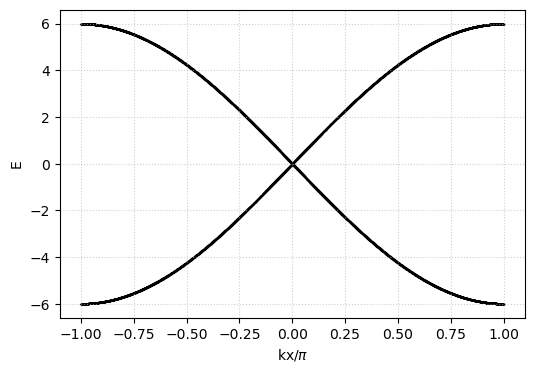

In [71]:
# 中间能带
ks1 = np.linspace(-1*np.pi, 1*np.pi,5001)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T* np.exp(-1j * k) + T .conj().T * np.exp(1j * k)

energies1 = []

for k in tqdm(ks1, desc="Calculating Bands"):
    H_k = Hk(k, H_q, T_21)
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

energies1 = np.array(energies1)

plt.figure(figsize=(6, 4))

for i in range(energies1.shape[1]):
    plt.scatter(ks1/np.pi, energies1[:, i], color='black', s=0.1)
#plt.ylim(-0.6,0.6)
#plt.xlim(-0.05,0.05)
plt.xlabel(r'kx/$\pi$')
plt.ylabel('E')
plt.grid(True, linestyle=':', alpha=0.6)
#save_fig_by_title_1(params_str)
plt.show()




Calculating Bands: 100%|██████████| 5001/5001 [00:00<00:00, 103459.62it/s]


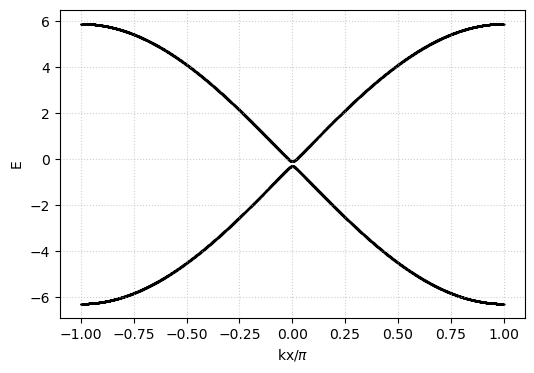

In [72]:
# 两边能带
ks1 = np.linspace(-1*np.pi, 1*np.pi,5001)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T* np.exp(-1j * k) + T .conj().T * np.exp(1j * k)

energies1 = []

for k in tqdm(ks1, desc="Calculating Bands"):
    H_k = Hk(k, H_l, T_l)
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

energies1 = np.array(energies1)

plt.figure(figsize=(6, 4))

for i in range(energies1.shape[1]):
    plt.scatter(ks1/np.pi, energies1[:, i], color='black', s=0.1)
#plt.ylim(-0.6,0.6)
#plt.xlim(-0.05,0.05)
plt.xlabel(r'kx/$\pi$')
plt.ylabel('E')
plt.grid(True, linestyle=':', alpha=0.6)
#save_fig_by_title_1(params_str)
plt.show()

In [73]:
#不同ky

max_duihaoshu = int(2 * m / 3)

matrix_dict = {}

for duihaoshu in range(0,max_duihaoshu + 1):  # +1 是为了包含 2*m/3 这个值本身
    
    # 根据当前的 duihaoshu 计算 ky
    ky = 2 * np.pi / 3 * 3 * duihaoshu / (b * 2 * m)
    
    # 1. 中心区器件矩阵
    H_q = H_onstie(mu_q, t)
    T_21 = H_hop(t, ky, b)
    
    # 建立中心区各层的列表 (使用列表推导式更简洁)
    H_q_list = [H_q for _ in range(xshumu)]
    
    # 2. 左右电极及耦合矩阵
    H_l = H_onstie(mu_l, t)
    T_l = H_hop(t, ky, b).conj().T
    
    H_r = H_onstie(mu_r, t)
    T_r = H_hop(t, ky, b)
    
    T_LD = H_hop(t, ky, b)
    T_RD = H_hop(t, ky, b).conj().T


    # 3. 将这一组参数打包存入字典
    matrix_dict[duihaoshu] = {
        "H_q_list": H_q_list,
        "T_21": T_21,
        "H_l": H_l,
        "T_l": T_l,
        "H_r": H_r,
        "T_r": T_r,
        "T_LD": T_LD,
        "T_RD": T_RD
    }


C:\Users\taoji\AppData\Local\Temp\ipykernel_29212\1202076138.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')
























Calculating all subbands: 100%|██████████| 23/23 [00:01<00:00, 22.20it/s]


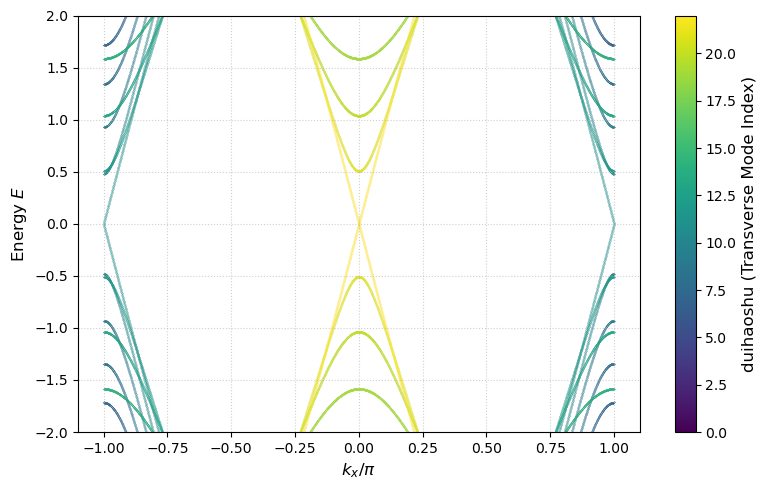

In [74]:
#ky(多个ky)画中间能带
# 重新定义 k 区间
ks1 = np.linspace(-1*np.pi, 1*np.pi, 5001)

def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

plt.figure(figsize=(8, 5)) # 稍微调宽一点，给右侧的 Colorbar 留出空间

# ================= 核心修改：设置色图 (Colormap) =================
# 'viridis' 是一种非常适合科研论文的渐变色谱，你可以改成 'jet', 'plasma' 等
cmap = cm.get_cmap('viridis')
# 将 duihaoshu 的范围映射到 0~1 的颜色空间
norm = colors.Normalize(vmin=0, vmax=max_duihaoshu)

# 外层循环：遍历字典里的所有 duihaoshu 模式
# 这里加了 tqdm 进度条，因为要算 40 多次矩阵对角化
for dhs, mats in tqdm(matrix_dict.items(), desc="Calculating all subbands"):
    
    # 提取当前 duihaoshu 对应的中心区哈密顿量和跃迁矩阵
    H_q = mats["H_q_list"][0] 
    T_21 = mats["T_21"]
    
    energies1 = []
    # 内层循环：计算当前模式的能带
    for k in ks1:
        H_k = Hk(k, H_q, T_21)
        evals1 = np.linalg.eigvalsh(H_k)
        energies1.append(evals1)
        
    energies1 = np.array(energies1)
    
    # 获取当前 duihaoshu 对应的颜色
    color = cmap(norm(dhs))
    
    # 画出当前 duihaoshu 的能带
    for i in range(energies1.shape[1]):
        # 因为线非常密集，散点大小设为极小 s=0.01
        # 如果你觉得散点图画出来太慢/太卡，强烈建议改成下一行的 plt.plot 连线
        plt.scatter(ks1/np.pi, energies1[:, i], color=color, s=0.01)
        
        # (备选推荐：画线比画百万个散点快很多，且适合用于出图)
        # plt.plot(ks1/np.pi, energies1[:, i], color=color, linewidth=0.5)

# ================= 设置坐标轴和颜色条 =================
plt.xlabel(r'$k_x/\pi$', fontsize=12)
plt.ylabel('Energy $E$', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# 添加右侧颜色条来标记 duihaoshu，完美解决图例太多的问题
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # 必须加上这句，为空数组
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('duihaoshu (Transverse Mode Index)', fontsize=12)

# 可选：限制可视范围放大局部特征
plt.ylim(-2, 2)

plt.tight_layout()
plt.show()

C:\Users\taoji\AppData\Local\Temp\ipykernel_29212\2291654788.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')



























Calculating Lead bands: 100%|██████████| 23/23 [00:01<00:00, 22.77it/s]


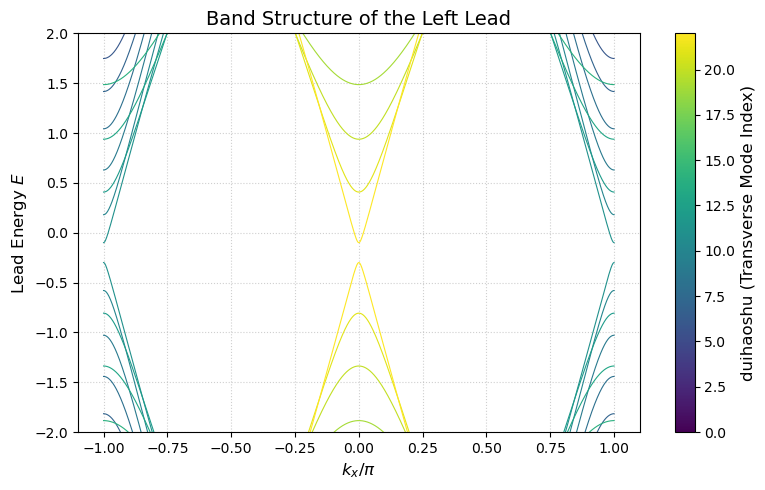

In [75]:
#ky(多个ky)画左边能带
# 定义 k 区间
ks1 = np.linspace(-1*np.pi, 1*np.pi, 5001)

def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

plt.figure(figsize=(8, 5)) # 保持宽比例，给 Colorbar 留位置

# ================= 设置色图 (Colormap) =================
cmap = cm.get_cmap('viridis')
# norm 将 duihaoshu 的范围 (0 到 max_duihaoshu) 映射到 0~1 的颜色空间
norm = colors.Normalize(vmin=0, vmax=max_duihaoshu)

# 遍历字典里的所有 duihaoshu 模式
for dhs, mats in tqdm(matrix_dict.items(), desc="Calculating Lead bands"):
    
    # ================= 核心修改 =================
    # 提取当前 duihaoshu 对应的【左电极】哈密顿量和跃迁矩阵
    H_l = mats["H_l"] 
    T_l = mats["T_l"]
    # ==========================================
    
    energies1 = []
    # 计算当前电极模式的能带
    for k in ks1:
        # 传入电极的 H_l 和 T_l
        H_k = Hk(k, H_l, T_l)
        evals1 = np.linalg.eigvalsh(H_k)
        energies1.append(evals1)
        
    energies1 = np.array(energies1)
    
    # 获取当前 duihaoshu 对应的颜色
    color = cmap(norm(dhs))
    
    # 画出当前电极模式的能带
    for i in range(energies1.shape[1]):
        # 使用 plot 画线，linewidth=0.8 既不会太细也不会互相粘连
        plt.plot(ks1/np.pi, energies1[:, i], color=color, linewidth=0.8)

# ================= 设置坐标轴和颜色条 =================
plt.xlabel(r'$k_x/\pi$', fontsize=12)
plt.ylabel('Lead Energy $E$', fontsize=12)
plt.title('Band Structure of the Left Lead', fontsize=14) # 改了标题
plt.grid(True, linestyle=':', alpha=0.6)

# 添加右侧颜色条
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('duihaoshu (Transverse Mode Index)', fontsize=12)
plt.ylim(-2, 2)
plt.tight_layout()
plt.show()

开始并行计算，总共 100 个能量点，启动 14 个线程...

















Calculating Total Conductance: 100%|██████████| 100/100 [00:01<00:00, 70.31it/s]


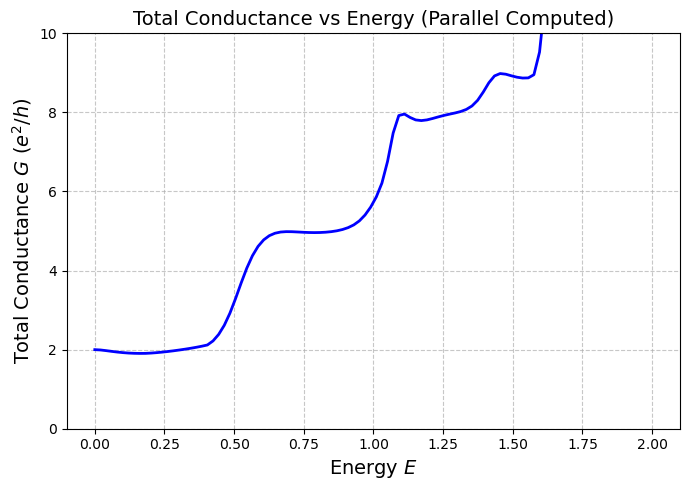

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed

# ================= 1. 封装单点计算函数 =================
def calc_G_total_at_E_1(E_val, matrix_dict, xshumu, eta):
    """
    计算给定单一能量点 E_val 下，所有 transverse modes 的总电导
    """
    G_total_at_E = 0.0  
    
    # 遍历字典中所有的横向模式
    for dhs, mats in matrix_dict.items():
        G_RL, Sigma_R, Sigma_L = Gr_DD_2(
            H_q_list=mats["H_q_list"],
            H_l=mats["H_l"],
            H_r=mats["H_r"],
            T_21=mats["T_21"],
            T_LD=mats["T_LD"],
            T_l=mats["T_l"],
            T_RD=mats["T_RD"],
            T_r=mats["T_r"],
            xshumu=xshumu, 
            E=E_val,
            eta=eta
        )
        
        # 计算左右电极的展宽矩阵
        zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
        zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)
        
        # 计算当前模式的透射率并累加
        G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
        G_total_at_E += np.real(G_complex)
        
    return G_total_at_E

# ================= 2. 参数设置与并行计算 =================
# 设置能量范围：从 -0.5 到 0.5，共 100 个点
E_vals = np.linspace(0, 2, 100)
eta = 1e-6

print(f"开始并行计算，总共 {len(E_vals)} 个能量点，启动 14 个线程...")

# 核心：使用 joblib 开启 14 个进程进行并行计算
# tqdm 用于在主进程中显示分配进度
G_total_list = Parallel(n_jobs=14)(
    delayed(calc_G_total_at_E_1)(E_val, matrix_dict, xshumu, eta) 
    for E_val in tqdm(E_vals, desc="Calculating Total Conductance")
)

# 将返回的列表转换为 numpy 数组以便画图
G_total_list = np.array(G_total_list)

# ================= 3. 画出物理图像 =================
plt.figure(figsize=(7, 5))

# 画线，使用稍粗的线条
plt.plot(E_vals, G_total_list, color='b', linewidth=2)

plt.xlabel(r'Energy $E$', fontsize=14)
plt.ylabel(r'Total Conductance $G \ (e^2/h)$', fontsize=14)
plt.title('Total Conductance vs Energy (Parallel Computed)', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.ylim(0,10)

plt.show()

In [77]:
#虚拟探针
total_sites = xshumu 
M = total_sites * 2  

# 设定基础的 T_d (目前作为统一初始值)
base_T_d = 0.05 * np.array([[1, 0], [0, 1]], dtype=complex)

# 核心修改：将每个格点的 T_d 和虚部自能存入列表，方便以后做成不一样的！
T_d_list = []
xushuzineng_list = []

for i in range(total_sites):
    # ---------------------------------------------------------
    # 未来你可以在这里写 if/else 逻辑！
    # 比如：前 xshumu 个 (即 i < xshumu) 是某种 T_d_edge
    # 其他的是 T_d_bulk 等等。
    # 现在我们先让它们统统等于 base_T_d
    # ---------------------------------------------------------
    current_T_d = base_T_d.copy()  
    
    T_d_list.append(current_T_d)
    xushuzineng_list.append(-1j * current_T_d / 2)


# 既然每个格点可能不一样了，就不能用 kron，改为手动分块组装大自能矩阵
Sigma_virtual_big = np.zeros((M, M), dtype=complex)
for i in range(total_sites):
    start_idx = 2 * i
    end_idx = 2 * i + 2
    Sigma_virtual_big[start_idx:end_idx, start_idx:end_idx] = xushuzineng_list[i]


启动并行计算，共 150 个能量点，14 线程火力全开...
































Calculating Dephasing G: 100%|██████████| 150/150 [00:02<00:00, 70.32it/s]


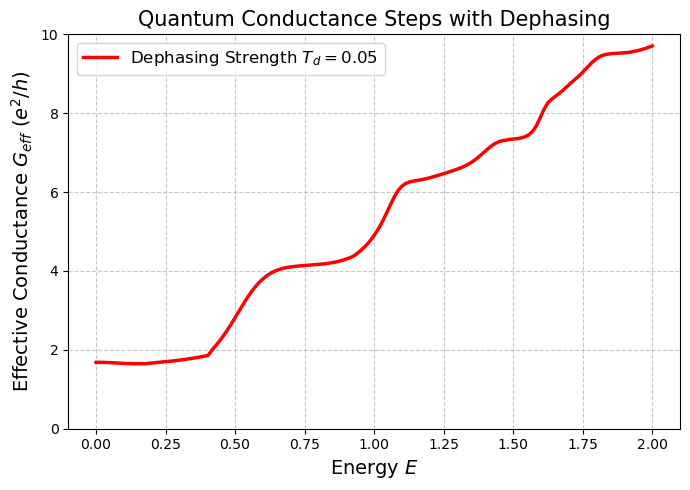

In [78]:


# ==========================================================
# 4. 并行扫描能量 E 并画图
# ==========================================================
# 设置扫描范围，由于碳纳米管能带是对称的，我们可以看 -0.5 到 0.5 
E_vals = np.linspace(0, 2, 150)  # 先用 150 个点测试速度
eta = 1e-6

print(f"启动并行计算，共 {len(E_vals)} 个能量点，14 线程火力全开...")

# 使用 joblib 进行并行加速 (调用你之前定义的 calc_G_total_at_E 和相关函数)
G_total_list = Parallel(n_jobs=14)(
    delayed(calc_G_total_at_E)(E_val, matrix_dict, xshumu, T_d_list, Sigma_virtual_big, eta)
    for E_val in tqdm(E_vals, desc="Calculating Dephasing G")
)

G_total_list = np.array(G_total_list)

# 绘制最终的物理图像
plt.figure(figsize=(7, 5))
plt.plot(E_vals, G_total_list, color='red', linewidth=2.5, label=f'Dephasing Strength $T_d = {base_T_d[0,0].real}$')

plt.xlabel(r'Energy $E$', fontsize=14)
plt.ylabel(r'Effective Conductance $G_{eff} \ (e^2/h)$', fontsize=14)
plt.title('Quantum Conductance Steps with Dephasing', fontsize=15)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.ylim(0,10)
plt.show()